<div style=" background-color: RGB(35,114,00);" >
<h1 style="margin: auto; padding: 60px 0; color:#fff; text-align: center">ANALYSE DES VENTES D'UNE LIBRAIRIE</h1>
</div>

<h2 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) ">I - Nettoyage et traitement des tables </h2>

<h3 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 1.1- Chargement des librairies et définition des fonctions </h3>


In [3]:
# Importer les librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm

In [9]:
# Défininir d'une fonction qui affiche la distribution de la variable

def distribution_variable (
    data_frame: pd.DataFrame,
    var: str = "price",
    xlabel: str = "Densité",
    ylabel: str = "valeur",
    title: str = "show title",
    fig_dimension: tuple = (12, 6)) -> None:

    # Extraire la colonne 
    variable = data_frame[var].dropna()

    # Calculer la moyenne et l'écart type
    mean_variable = variable.mean()
    std_variable = variable.std()
    
    # Afficher les valeurs calculées
    print(f"Moyenne variable : {mean_variable}")
    print(f"Écart type de la variable : {std_variable}")
    
    # Tracer l'histogramme avec une courbe gaussienne
    plt.figure(figsize=fig_dimension)
    
    # Histogramme
    
    plt.hist(variable, bins=10, density=True, color='skyblue', edgecolor='black', alpha=0.6)
    
    # Ajustement gaussien
    mu, std = norm.fit(variable)
    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, variable.count())
    p = norm.pdf(x, mu, std)
    
    # Tracer la courbe gaussienne
    plt.plot(x, p, 'k', linewidth=2, label='Ajustement Gaussien')
    
    # Ajouter les titres et légendes en français
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    
    # Afficher le graphique
    plt.show()

<h3 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 1.2- Analyse de la table customers </h3>

<h4 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 1.2.1- Description de la table </h4>

In [104]:
# Charger et décrire la table customers 

df_cust = pd.read_csv("customers.csv")

df_cust.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8623 entries, 0 to 8622
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   client_id  8623 non-null   object
 1   sex        8623 non-null   object
 2   birth      8623 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 202.2+ KB


,birth
count,8623.000000
mean,1978.280877
std,16.919535
min,1929.000000
25%,1966.000000
50%,1979.000000
75%,1992.000000
max,2004.000000


In [19]:
# Afficher la table

df_cust

,client_id,sex,birth
0,c_4410,f,1967
1,c_7839,f,1975
2,c_1699,f,1984
3,c_5961,f,1962
4,c_5320,m,1943
...,...,...,...
8618,c_7920,m,1956
8619,c_7403,f,1970
8620,c_5119,m,1974
8621,c_5643,f,1968


<h4 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 1.2.2- Recherche des anomalies </h4>

In [21]:

# Définir une liste d'identifiant unique

id_unique = df_cust["client_id"].unique().tolist()

# Rechercher les identifiants en double

print("On observe", len(id_unique), "identifiants uniques. Soit le nombre total de lignes de la table df_cust")

On observe 8623 identifiants uniques. Soit le nombre total de lignes de la table df_cust


In [29]:
# 2e méthode de vérification de l'existence des doublons

mask = df_cust["client_id"].duplicated(keep=False)

df_cust.loc[mask, :]

,client_id,sex,birth


In [31]:
# Imprimer les identifiants client qui ne sont pas au bon format

for id in id_unique:
    if "c_" not in id:
        print(id)

ct_0
ct_1


In [33]:
# Afficher les informations sur les clients avec un identifiant atypique

df_cust.loc[df_cust["client_id"].isin(["ct_0", "ct_1"]), :]

,client_id,sex,birth
2735,ct_0,f,2001
8494,ct_1,m,2001


In [41]:
# Supprimer les deux observations avec les identifiants atypiques 
mask_indices = ~df_cust.index.isin([2735, 8494])

df_cust = df_cust[mask_indices]


# Vérifier s'il existe des anomalies dans la variable sex

print("Les modalités de la variables sex sont: ", df_cust["sex"].unique().tolist())


# Vérifier s'il existe des anomalies dans la variable birth

print("Les modalités de la variables birth sont: ", df_cust["birth"].unique().tolist())

Les modalités de la variables sex sont:  ['f', 'm']
Les modalités de la variables birth sont:  [1967, 1975, 1984, 1962, 1943, 1993, 1978, 1971, 1982, 1945, 2003, 1959, 1977, 1954, 1987, 2000, 1992, 1963, 1958, 1994, 1936, 1986, 1942, 1970, 1957, 1968, 2002, 2004, 1979, 1974, 1964, 1951, 1937, 1981, 1965, 1960, 1996, 1983, 1990, 1955, 1988, 1991, 1972, 1980, 1989, 1976, 1985, 1953, 1998, 1956, 1948, 1973, 1969, 1938, 1995, 1952, 1949, 1999, 2001, 1939, 1950, 1966, 1935, 1941, 1961, 1997, 1944, 1929, 1947, 1946, 1932, 1931, 1933, 1930, 1940, 1934]


In [43]:
# Sauvegarder la table customers

df_cust.to_csv("df_customers", index = False)

<h3 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 1.3- Analyse de la table products </h3>

<h4 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 1.3.1- Description de la table </h4>

In [64]:
# Charger la table 

df_prod = pd.read_csv("products.csv")

budgets = df_prod['price'].dropna()


# Afficher la table 

df_prod

,id_prod,price,categ
0,0_1421,19.99,0
1,0_1368,5.13,0
2,0_731,17.99,0
3,1_587,4.99,1
4,0_1507,3.99,0
...,...,...,...
3282,2_23,115.99,2
3283,0_146,17.14,0
3284,0_802,11.22,0
3285,1_140,38.56,1


In [106]:
# Décrire  la table

df_prod.info()


<class 'pandas.core.frame.DataFrame'>
Index: 3286 entries, 0 to 3286
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_prod            3286 non-null   object 
 1   price              3286 non-null   float64
 2   categ              3286 non-null   int64  
 3   categorie_produit  3286 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 128.4+ KB


,price,categ
count,3286.000000,3286.000000
mean,21.863597,0.370359
std,29.849786,0.615446
min,0.620000,0.000000
25%,6.990000,0.000000
50%,13.075000,0.000000
75%,22.990000,1.000000
max,300.000000,2.000000


<h4 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 1.3.2- Recherche des anomalies </h4>

In [68]:
# Vérifier l'existence d'identifiants produit en double

mask = df_prod["id_prod"].duplicated(keep=False)

df_prod.loc[mask, :]

,id_prod,price,categ


On n'observe pas d'identifiants en  double

In [71]:
# Rechercher les valeurs de l'identifiant id_prod atypique et donc ne commencant pas par un chiffre

liste_id_prod = df_prod["id_prod"].unique().tolist()

for id in liste_id_prod:
    if  id[0]  not in ("0", "1", "2", "3", "4", "5", "6"):
        print(id)


T_0


In [73]:
# Identifier les anomalies sur la variable price

df_prod["price"].describe()

count    3287.000000
mean       21.856641
std        29.847908
min        -1.000000
25%         6.990000
50%        13.060000
75%        22.990000
max       300.000000
Name: price, dtype: float64

In [75]:
# Afficher les données avec des prix négatifs 

df_prod.loc[df_prod["price"] < 0, :]

,id_prod,price,categ
731,T_0,-1.0,0


On observe une seule observation avec un prix négatif. Cette observation dispose d'une valeur id_prod atypique, soit  T_0. Cette observation sera donc supprimée. 

In [80]:
# Supprimer les observations avec le prix négatif

mask_indices = ~df_prod.index.isin([731])

df_prod= df_prod[mask_indices]


# Modalités de la variable categ

print(df_prod["categ"].unique().tolist())


[0, 1, 2]


In [82]:
# Créeer une nouvelle variable de la catégorie de produit
 
pd.options.mode.copy_on_write = True 

df_prod["categorie_produit"] = "NA"

df_prod.loc[df_prod["categ"] == 0, ["categorie_produit"]] = "catégorie 0"
df_prod.loc[df_prod["categ"] == 1, ["categorie_produit"]] = "catégorie 1"
df_prod.loc[df_prod["categ"] == 2, ["categorie_produit"]] = "catégorie 2"

df_prod.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3286 entries, 0 to 3286
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_prod            3286 non-null   object 
 1   price              3286 non-null   float64
 2   categ              3286 non-null   int64  
 3   categorie_produit  3286 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 128.4+ KB


In [84]:
# Sauvegarder la table 

df_prod.to_csv("df_productions", index = False)

<h3 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 1.4- Analyse de la table transaction </h3>

<h4 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 1.4.1- Description de la table </h4>

In [111]:
# Charger la table 

df_trans = pd.read_csv("transactions.csv")


# Afficher la table

df_trans

,id_prod,date,session_id,client_id
0,0_1518,2022-05-20 13:21:29.043970,s_211425,c_103
1,1_251,2022-02-02 07:55:19.149409,s_158752,c_8534
2,0_1277,2022-06-18 15:44:33.155329,s_225667,c_6714
3,2_209,2021-06-24 04:19:29.835891,s_52962,c_6941
4,0_1509,2023-01-11 08:22:08.194479,s_325227,c_4232
...,...,...,...,...
679527,0_1551,2022-01-15 13:05:06.246925,s_150195,c_8489
679528,1_639,2022-03-19 16:03:23.429229,s_181434,c_4370
679529,0_1425,2022-12-20 04:33:37.584749,s_314704,c_304
679530,0_1994,2021-07-16 20:36:35.350579,s_63204,c_2227


In [113]:
# Décrire la table

df_trans.info()

df_trans.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 679532 entries, 0 to 679531
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id_prod     679532 non-null  object
 1   date        679532 non-null  object
 2   session_id  679532 non-null  object
 3   client_id   679532 non-null  object
dtypes: object(4)
memory usage: 20.7+ MB


,id_prod,date,session_id,client_id
count,679532,679532,679532,679532
unique,3267,679371,342316,8602
top,1_369,test_2021-03-01 02:30:02.237413,s_0,c_1609
freq,2252,13,200,25488


<h4 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 1.4.2- Recherche des anomalies </h4>

In [116]:
# Identifier les doublons

mask = df_trans["session_id"].duplicated(keep=False)

df_count = df_trans.loc[mask, : ].value_counts().reset_index()


# Afficher les observations avec l'identifiant session_id en double

df_count.loc[df_count["count"] >1, :].head(10)

,id_prod,date,session_id,client_id,count
0,T_0,test_2021-03-01 02:30:02.237413,s_0,ct_0,9
1,T_0,test_2021-03-01 02:30:02.237428,s_0,ct_0,6
2,T_0,test_2021-03-01 02:30:02.237446,s_0,ct_0,6
3,T_0,test_2021-03-01 02:30:02.237412,s_0,ct_1,5
4,T_0,test_2021-03-01 02:30:02.237414,s_0,ct_1,5
5,T_0,test_2021-03-01 02:30:02.237443,s_0,ct_1,5
6,T_0,test_2021-03-01 02:30:02.237427,s_0,ct_1,4
7,T_0,test_2021-03-01 02:30:02.237441,s_0,ct_0,4
8,T_0,test_2021-03-01 02:30:02.237430,s_0,ct_1,4
9,T_0,test_2021-03-01 02:30:02.237432,s_0,ct_0,4


In [118]:
# Afficher les observations avec l'identifiant session_id unique

df_count.loc[df_count["count"] ==1, :]

,id_prod,date,session_id,client_id,count
57,1_147,2021-06-14 13:19:42.305640,s_48567,c_6526,1
58,1_145,2023-02-27 23:14:27.205591,s_347946,c_2586,1
59,1_146,2021-07-22 04:11:29.144620,s_65518,c_4435,1
60,1_146,2021-12-31 05:01:22.475539,s_142694,c_4491,1
61,1_147,2021-03-05 08:23:35.615501,s_2010,c_6621,1
...,...,...,...,...,...
516051,0_1465,2022-08-28 09:00:47.122476,s_259666,c_2908,1
516052,0_1465,2022-08-27 23:13:47.407368,s_259443,c_8035,1
516053,0_1465,2022-08-26 09:32:51.358989,s_258678,c_2146,1
516054,0_1465,2022-08-26 00:46:53.348407,s_258488,c_1789,1


Les observations avec un identifiant session en double correspondent aux observations avec l'id produit atypique. soit T_0. Cette observation a été supprimée dans la table de production. nous décidons de la supprimer également dans la table des transaction 

In [121]:
# Supprimer les transactions correspondant à l'id prod T_0

df_trans = df_trans.loc[df_trans["id_prod"] != "T_0", : ].copy()

In [123]:
# Vérifier à nouveau s'il existe des observations avec la variable session_id en double

mask = df_trans["session_id"].duplicated(keep=False)

df_count2 = df_trans.loc[mask, : ].value_counts().reset_index()

df_count2.loc[df_count2["count"] >1, :]


,id_prod,date,session_id,client_id,count


In [125]:
# Vérifier s'il existe des anomalies sur la variable date

pd.to_datetime(df_trans["date"])


0        2022-05-20 13:21:29.043970
1        2022-02-02 07:55:19.149409
2        2022-06-18 15:44:33.155329
3        2021-06-24 04:19:29.835891
4        2023-01-11 08:22:08.194479
                    ...            
679527   2022-01-15 13:05:06.246925
679528   2022-03-19 16:03:23.429229
679529   2022-12-20 04:33:37.584749
679530   2021-07-16 20:36:35.350579
679531   2022-09-28 01:12:01.973763
Name: date, Length: 679332, dtype: datetime64[ns]

In [127]:
# Mettre la variable date au format date


df_trans["date"] = pd.to_datetime(df_trans["date"],
                                  dayfirst=True,
                                  errors="coerce").dt.normalize()


df_trans.head(10)

C:\Users\Fujitsu\AppData\Local\Temp\ipykernel_10488\2030951278.py:4: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S.%f format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_trans["date"] = pd.to_datetime(df_trans["date"],


,id_prod,date,session_id,client_id
0,0_1518,2022-05-20,s_211425,c_103
1,1_251,2022-02-02,s_158752,c_8534
2,0_1277,2022-06-18,s_225667,c_6714
3,2_209,2021-06-24,s_52962,c_6941
4,0_1509,2023-01-11,s_325227,c_4232
5,0_1418,2022-10-20,s_285425,c_1478
6,0_1475,2022-06-03,s_218033,c_7782
7,0_2110,2021-06-26,s_54122,c_7456
8,0_1156,2022-12-27,s_318058,c_7363
9,1_299,2021-11-29,s_126880,c_1847


In [93]:
# Sauvegarder la table 

df_trans.to_csv("df_transactions", index = False)

<h2 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> II - Analyse des données </h2
                                                                                                                    >

In [129]:

# Charger les tables
df_prod = pd.read_csv("df_productions")
df_trans = pd.read_csv("df_transactions")
df_clients = pd.read_csv("df_customers")


<h3 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 2.1- Analyse du chiffre d'affaires </h3>

In [131]:
# Calcul de la quantité de produits vendue par jour 
df_qte_produit = df_trans.groupby(["date", "id_prod"]).size().reset_index(name="quantite")


# Associer le prix de chaque produit aux quantités vendues
df_ca_produits = pd.merge(df_qte_produit, df_prod, on="id_prod", how="left")


In [133]:
df_ca_produits

,date,id_prod,quantite,price,categ,categorie_produit
0,2021-03-01,0_0,1,3.75,0.0,catégorie 0
1,2021-03-01,0_1,1,10.99,0.0,catégorie 0
2,2021-03-01,0_1000,1,6.84,0.0,catégorie 0
3,2021-03-01,0_1003,1,14.99,0.0,catégorie 0
4,2021-03-01,0_1007,1,4.99,0.0,catégorie 0
...,...,...,...,...,...,...
449010,2023-02-28,2_44,1,70.92,2.0,catégorie 2
449011,2023-02-28,2_54,1,89.43,2.0,catégorie 2
449012,2023-02-28,2_62,1,60.96,2.0,catégorie 2
449013,2023-02-28,2_7,1,69.99,2.0,catégorie 2


In [135]:
# les produits avec plus de 5 unités vendues 
df_ca_produits.loc[df_ca_produits["quantite"] > 5, : ]


,date,id_prod,quantite,price,categ,categorie_produit
246,2021-03-01,0_1591,7,9.99,0.0,catégorie 0
486,2021-03-01,1_381,7,15.99,1.0,catégorie 1
498,2021-03-01,1_406,7,24.81,1.0,catégorie 1
504,2021-03-01,1_417,6,20.99,1.0,catégorie 1
842,2021-03-02,0_1454,6,7.41,0.0,catégorie 0
...,...,...,...,...,...,...
448247,2023-02-27,1_407,8,15.99,1.0,catégorie 1
448845,2023-02-28,1_379,7,26.99,1.0,catégorie 1
448847,2023-02-28,1_383,7,28.99,1.0,catégorie 1
448864,2023-02-28,1_414,7,23.83,1.0,catégorie 1


<h4 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 2.1.1 - Evolution du chiffre d'affaires </h4>

In [137]:
# Charger les librairies
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates


<h5 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> i)  Evolution par  jours </h5>

In [149]:
# Trier les données par date de début de voyage
data_sorted = df_ca_produits.sort_values("date")

# Calcul du montant total des vendes de chaque produits

data_sorted["montant_vente"] = data_sorted["quantite"] * data_sorted["price"]

In [151]:
data_sorted

,date,id_prod,quantite,price,categ,categorie_produit,montant_vente
0,2021-03-01,0_0,1,3.75,0.0,catégorie 0,3.75
427,2021-03-01,1_248,1,10.75,1.0,catégorie 1,10.75
428,2021-03-01,1_249,2,22.99,1.0,catégorie 1,45.98
429,2021-03-01,1_251,2,15.99,1.0,catégorie 1,31.98
430,2021-03-01,1_256,2,26.05,1.0,catégorie 1,52.10
...,...,...,...,...,...,...,...
448607,2023-02-28,0_1568,2,4.00,0.0,catégorie 0,8.00
448608,2023-02-28,0_1579,1,3.99,0.0,catégorie 0,3.99
448609,2023-02-28,0_1580,1,13.26,0.0,catégorie 0,13.26
448602,2023-02-28,0_1557,2,6.99,0.0,catégorie 0,13.98


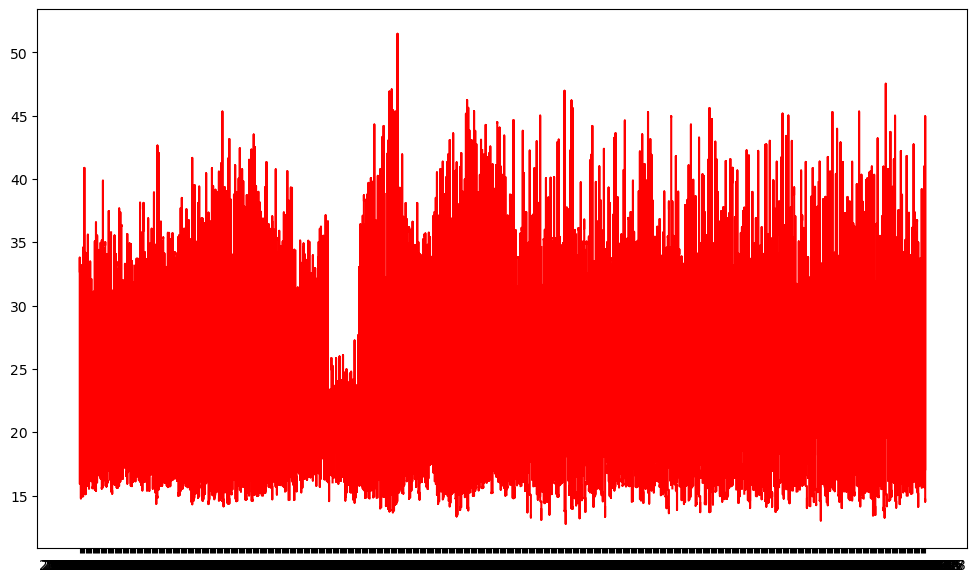

In [159]:

# Création du graphique en ligne
plt.figure(figsize=(12, 7))
#plt.plot(data_sorted['date'], data_sorted['montant_vente'], marker="o", linestyle='-', color='royalblue', label="Prix")
plt.plot(data_sorted['date'], data_sorted['montant_vente'].rolling(300).mean(), linestyle='-', color='red', label="Moyenne mobile 30 jours")


In [59]:
# Evolution du chiffre d'affaires par mois

data_sorted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 449015 entries, 0 to 449014
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   date               449015 non-null  object 
 1   id_prod            449015 non-null  object 
 2   quantite           449015 non-null  int64  
 3   price              448821 non-null  float64
 4   categ              448821 non-null  float64
 5   categorie_produit  448821 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 24.0+ MB


In [ ]:

# Charger les données
data = pd.read_csv('chemin_vers_ton_fichier.csv')  # Remplace par le chemin réel vers ton fichier CSV
data['date de début de voyage'] = pd.to_datetime(data['date de début de voyage'], dayfirst=True)  # Assure-toi que le format de la date est correct

# Trier les données par date de début de voyage
data_sorted = data.sort_values('date de début de voyage')

# Création du graphique en ligne
plt.figure(figsize=(12, 7))
plt.plot(data_sorted['date de début de voyage'], data_sorted['prix total'], marker="o", linestyle='-', color='royalblue', label="Prix")
plt.plot(data_sorted['date de début de voyage'], data_sorted['prix total'].rolling(30).mean(), linestyle='-', color='red', label="Moyenne mobile 30 jours")

# Formater l'axe des X pour afficher les dates correctement
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gcf().autofmt_xdate()  # Rotation automatique des dates pour une meilleure lisibilité

plt.legend()

plt.title('Évolution du Prix Total des Voyages en Fonction de la Date de Début')
plt.xlabel('Date de Début de Voyage')
plt.ylabel('Prix Total')
plt.grid(True)
plt.show()

<h4 style="margin: auto; padding: 20px; color:#fff; background-color: RGB(0,114,100) "> 2.1.2 - Distribution du chiffre d'affaires </h4>

In [148]:
# Calcul de la quantité totale de chaque produit vendu
nbre_produits_vendus = df_trans["id_prod"].value_counts().reset_index(name="qte_totale_vendue")

# Jointure avec la table des prix des produits
df_ca_produits = pd.merge(nbre_produits_vendus, df_prod, on="id_prod", how="left")

# Calcul du chiffre d'affaire par produit
df_ca_produits["ca_produit"] = df_ca_produits["qte_totale_vendue"] * df_ca_produits["price"]

# calcul du chiffre d'affaires total par catégorie de produit
data = df_ca_produits.groupby("categorie_produit")["ca_produit"].sum().reset_index()

# Mettre le chiffre d'affaires en milions
data["ca_produit_en_millions"] = data["ca_produit"] / 1000_000

In [150]:
data

,categorie_produit,ca_produit,ca_produit_en_millions
0,catégorie 0,4419730.97,4.419731
1,catégorie 1,4653722.69,4.653723
2,catégorie 2,2780275.02,2.780275


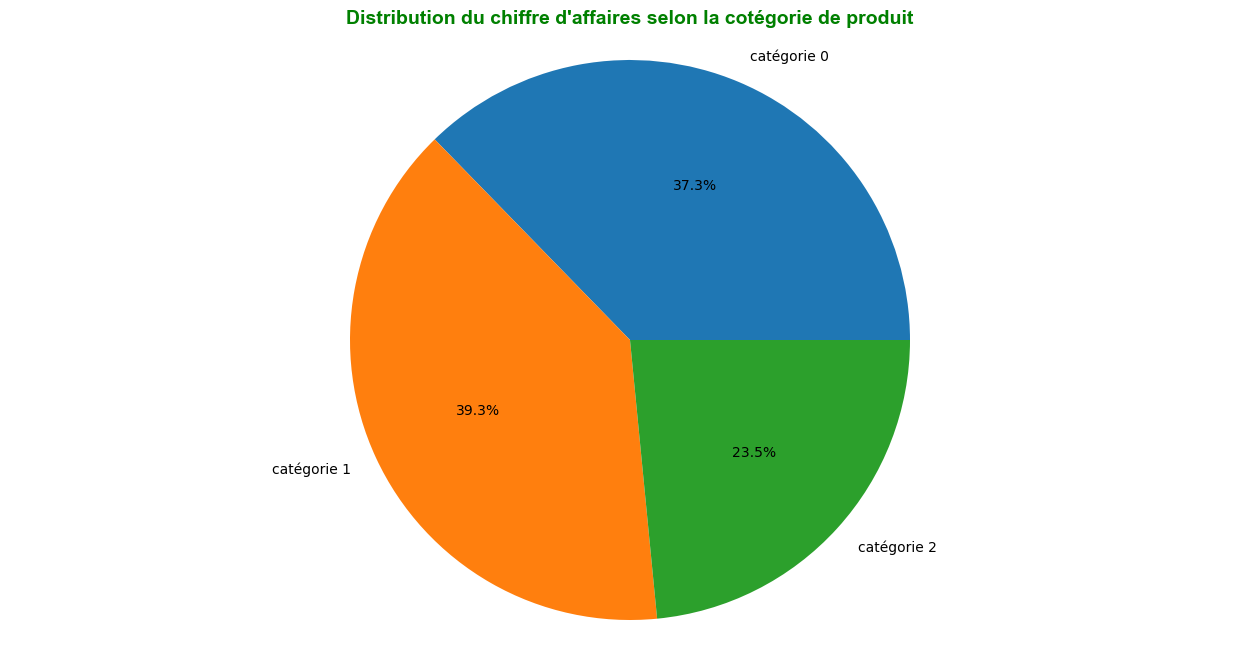

In [152]:
# Représenter le chiffre d'affaires par catégorie 

plt.figure(figsize=(16, 8))
plt.pie(x=data["ca_produit_en_millions"], labels=data["categorie_produit"], autopct='%.1f%%')
plt.title("Distribution du chiffre d'affaires selon la cotégorie de produit", color="green", fontweight="bold", fontname="Arial", fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()

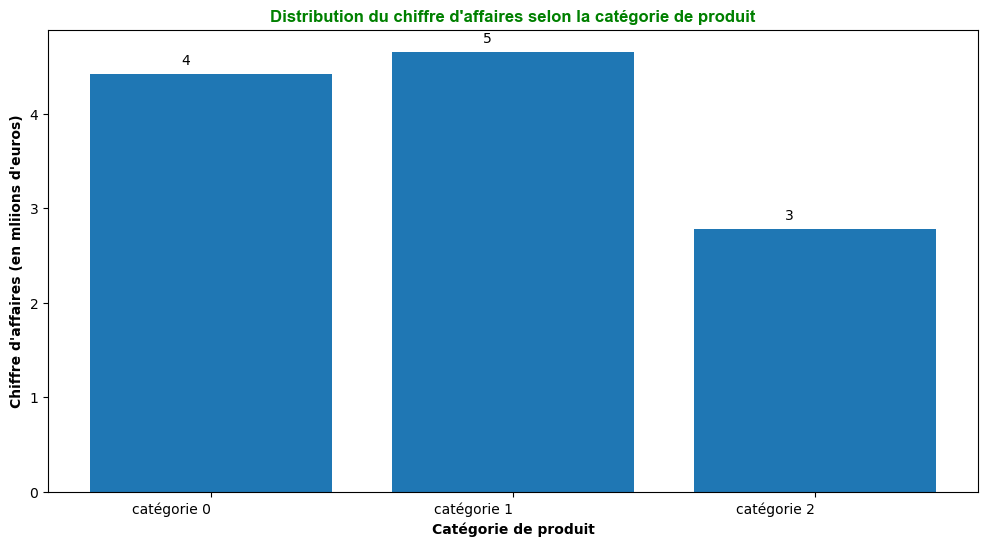

In [172]:
# 2e présentation : diagramme à barre

plt.figure(figsize=(12,6))
plt.bar(height=data["ca_produit_en_millions"], x=data["categorie_produit"])

plt.title("Distribution du chiffre d'affaires selon la catégorie de produit",
          color="green", fontweight="bold", fontname="Arial", fontsize=12)
plt.xlabel("Catégorie de produit", fontweight ="bold")
plt.ylabel("Chiffre d'affaires (en mliions d'euros)", fontweight ="bold")
plt.xticks(rotation=0, ha='right')  # ha='right' = alignement à droite


# Afficher les valeurs associées à chaque type de produit

val_niv = data["ca_produit_en_millions"].tolist()

for i in range(3):
    plt.text(i-0.1, val_niv[i]+0.1, round(val_niv[i]))

plt.show()